$\textit{\textbf{Write Python code to implement a Logistic Regression Model for Spam detection}}$

Logistic regression is often mentioned in connection to classification tasks. The model is simple and one of the easy starters to learn about generating probabilities, classifying samples, and understanding gradient descent

Logistic regression as mentioned above is mostly used for classification tasks thats why the output of this is in most cases is 1/0, yes/no etc or in form of probalility of 1. 

In linear regration the main equation us y = mx + c. 

and here the main equation is => $\sigma(z) = \frac{1}{1+e^-z} = h$

where $z = wx + b$

From the above the Liklyhood fuction is $l = \prod_{i = 1}^{m}[h^y][1-h]^{1-y}$

Loss Liklyhood Function => $L = ln(l) = \sum_{i=1}^{m} yln(h) + (1-y)ln(1-h)$

nagative average loss likelyhood fucntion => $J = -\frac{1}{m} L$ 

Now for gradiant decent we need 2 functions
1. $\frac{\delta J}{\delta w} = \frac{\delta J}{\delta h} \times \frac{\delta h}{\delta z} \times \frac{\delta z}{\delta w} \\\\ \hspace{0.5cm}= \sum_{i=1}^{m} [[\frac{y}{h} - \frac{1-y}{1-h}] \times [h (1-h)] \times x] \\\\ \hspace{0.5cm}= \sum_{i=1}^{m}(y-h)x$

2. $\frac{\delta J}{\delta b} = \frac{\delta J}{\delta h} \times \frac{\delta h}{\delta z} \times \frac{\delta z}{\delta b} \\\\ \hspace{0.5cm}= \sum_{i=1}^{m} [[\frac{y}{h} - \frac{1-y}{1-h}] \times [h (1-h)]] \\\\ \hspace{0.5cm}= \sum_{i=1}^{m}(y-h)$

$\textbf{Logistic Regression with one feature}$

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [22]:
x_data = np.array(list(range(100)))
y_data = np.concatenate((np.zeros(50),np.ones(50)),axis = 0)

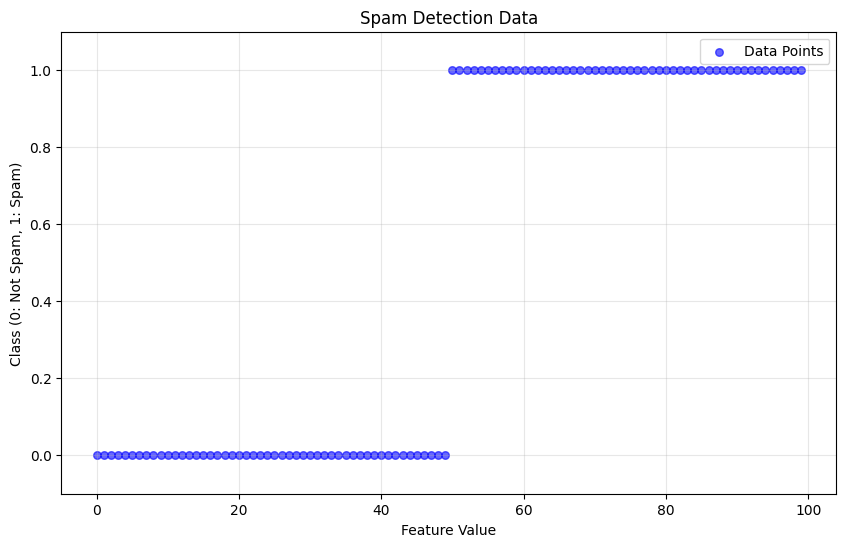

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color="blue", label='Data Points', alpha=0.6, s=30)
plt.xlabel('Feature Value')
plt.ylabel('Class (0: Not Spam, 1: Spam)')
plt.title('Spam Detection Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)  # Add some padding
plt.show()


In [24]:
def sigmoid(w,b,x):
    return 1 / (1 + np.exp(-((x*w)+b)))

In [25]:
def gradient_decent(w_now, b_now, x, y, L):
    w_grad = 0
    b_grad = 0
    n = len(x)

    for i in range(n):
        h_i = sigmoid(w_now, b_now, x[i])
        
        w_grad += (1/n) * (y[i] - h_i) * x[i]  
        b_grad += (1/n) * (y[i] - h_i)         
    
    w_l = w_now + L * w_grad  
    b_l = b_now + L * b_grad
    
    return (w_l, b_l)

In [26]:
m = 0 
b = 0
L = 0.1  # Increased learning rate
epochs = 5000  # Increased epochs

for i in range(epochs):
    m, b = gradient_decent(m, b, x_data, y_data, L)  # Update m and b!
    
print(f"Final w: {m}, Final b: {b}")


Final w: 1.142541404978092, Final b: -45.12369357247058


In [27]:
h = []
for i in x_data:
    h.append(sigmoid(m, b, i))  # Use m and b, not w and b

In [28]:
h

[np.float64(2.5294661875406792e-20),
 np.float64(7.929180530305491e-20),
 np.float64(2.4855799295464985e-19),
 np.float64(7.791609186537599e-19),
 np.float64(2.4424550984692604e-18),
 np.float64(7.656424706652217e-18),
 np.float64(2.4000784835460778e-17),
 np.float64(7.523585678542553e-17),
 np.float64(2.35843710322085e-16),
 np.float64(7.393051408602035e-16),
 np.float64(2.317518201167574e-15),
 np.float64(7.264781909258439e-15),
 np.float64(2.277309242382616e-14),
 np.float64(7.13873788672406e-14),
 np.float64(2.237797909344374e-13),
 np.float64(7.01488072895535e-13),
 np.float64(2.198972098237243e-12),
 np.float64(6.893172493797394e-12),
 np.float64(2.1608199152166912e-11),
 np.float64(6.773575897094985e-11),
 np.float64(2.1233296725047522e-10),
 np.float64(6.656054298706651e-10),
 np.float64(2.0864898822895323e-09),
 np.float64(6.540571666516682e-09),
 np.float64(2.0502892288720438e-08),
 np.float64(6.427092326279227e-08),
 np.float64(2.0147163302306345e-07),
 np.float64(6.31557864

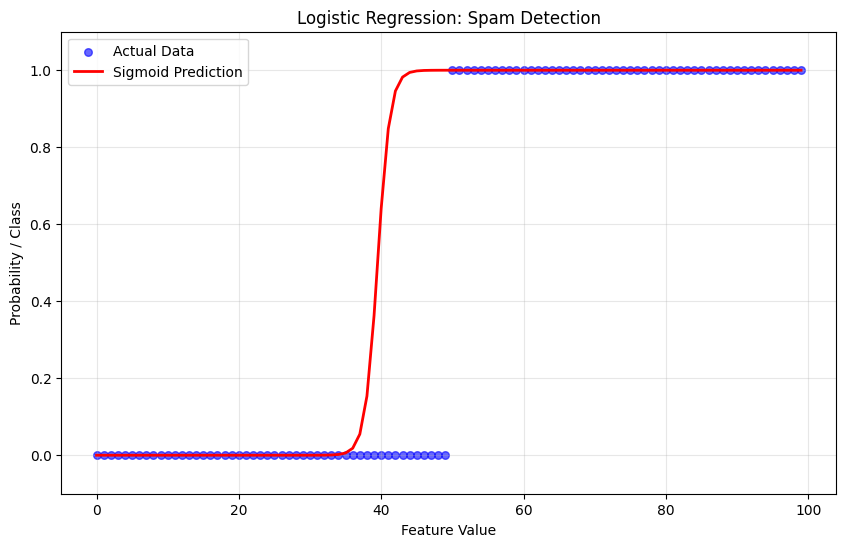

In [29]:
# Second plot - Data with sigmoid curve
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='blue', label='Actual Data', alpha=0.6, s=30)
plt.plot(x_data, h, label='Sigmoid Prediction', color="red", linewidth=2)
plt.xlabel('Feature Value')
plt.ylabel('Probability / Class')
plt.title('Logistic Regression: Spam Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.show()


In [32]:
sms_data = pd.read_csv('/home/rito/ju_lab/spam.csv',encoding="latin1")

In [33]:
sms_data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
